<a href="https://colab.research.google.com/github/catarina1532/avcad/blob/main/avcad_ex07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Analysis using the EFIplus_medit dataset

###1. Import libraries and dataset

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import probplot
from sklearn.ensemble import IsolationForest

# Load dataset
df = pd.read_csv('EFIplus_medit.csv', sep=';')

# Inspect first rows
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


###2. Visual inspection of continuous environmental variables

***prompt***: create a list with the continuous environmental variables to evaluate for potential transformation before parametric analysis

In [33]:
# Variables to inspect

variables = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

***prompt***: generate histograms with KDE curves for all selected environmental variables using subplots to visually assess skewness and distribution shape

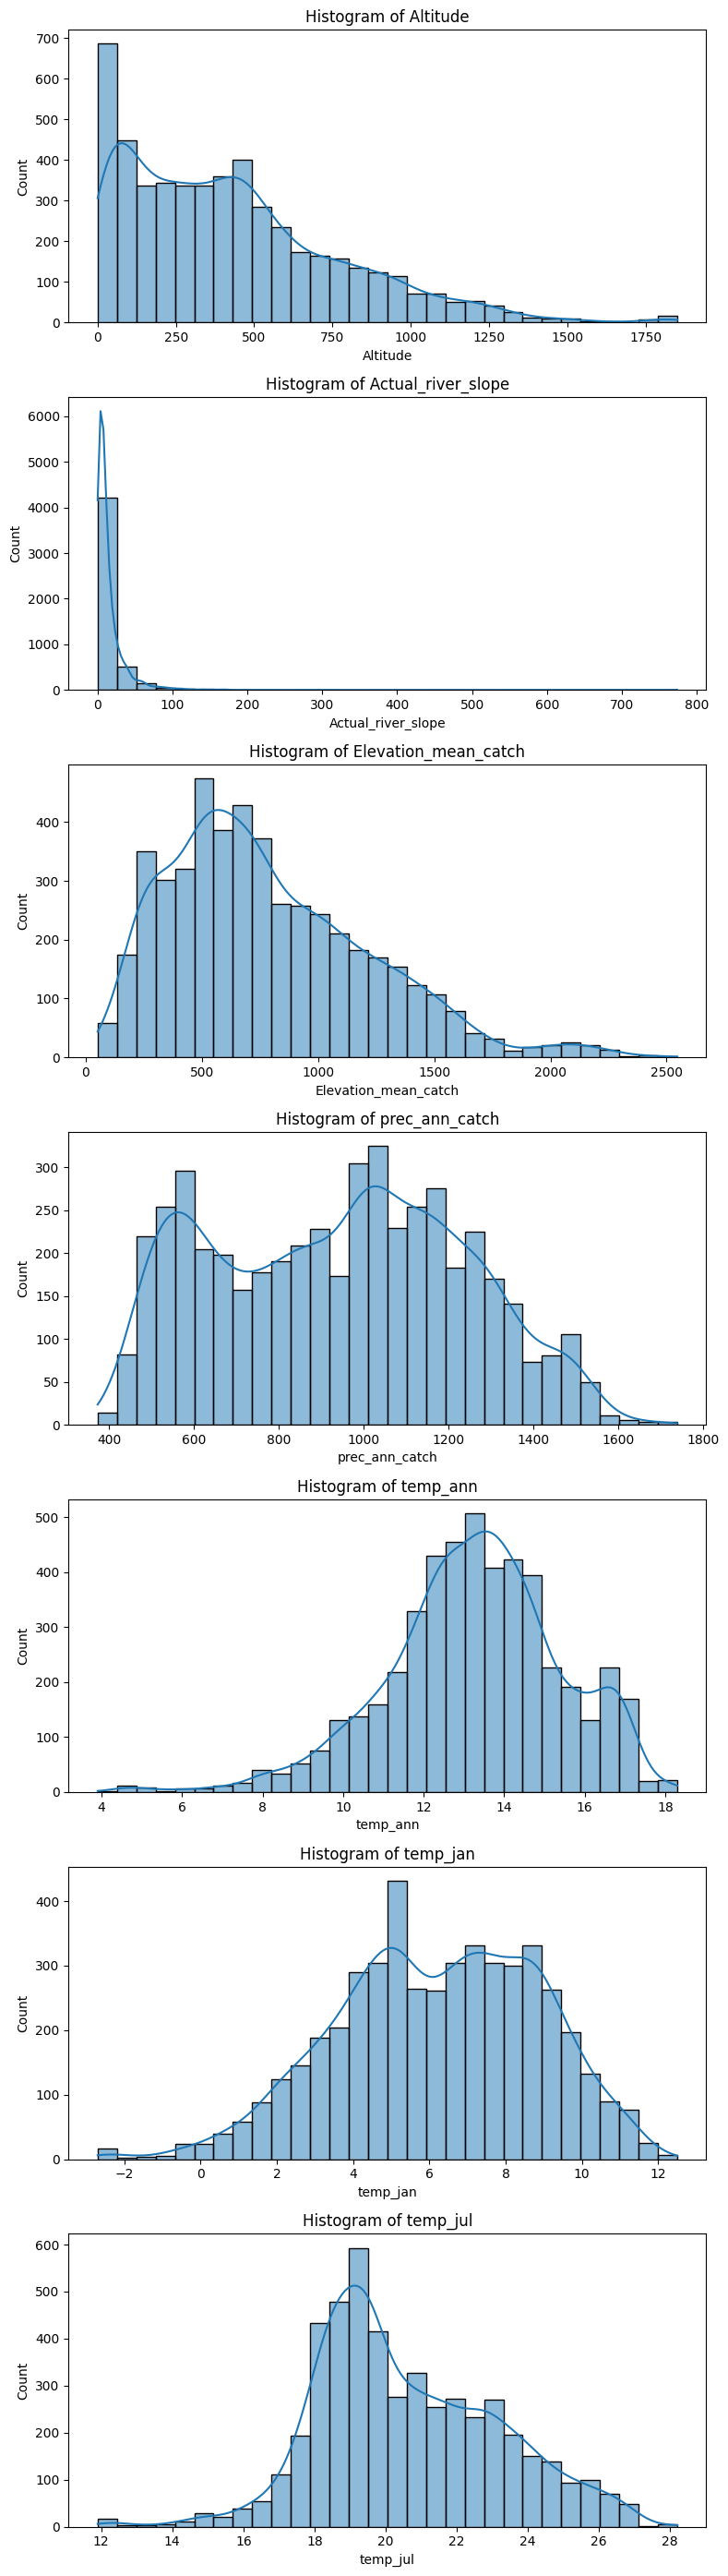

In [34]:
# Histograms

fig, axes = plt.subplots(len(variables), 1, figsize=(8, 28))

for ax, var in zip(axes, variables):
    sns.histplot(df[var], bins=30, kde=True, ax=ax)
    ax.set_title(f'Histogram of {var}')

plt.tight_layout()
plt.show()

***prompt***: generate Q-Q plots for all selected environmental variables to visually assess departures from normality

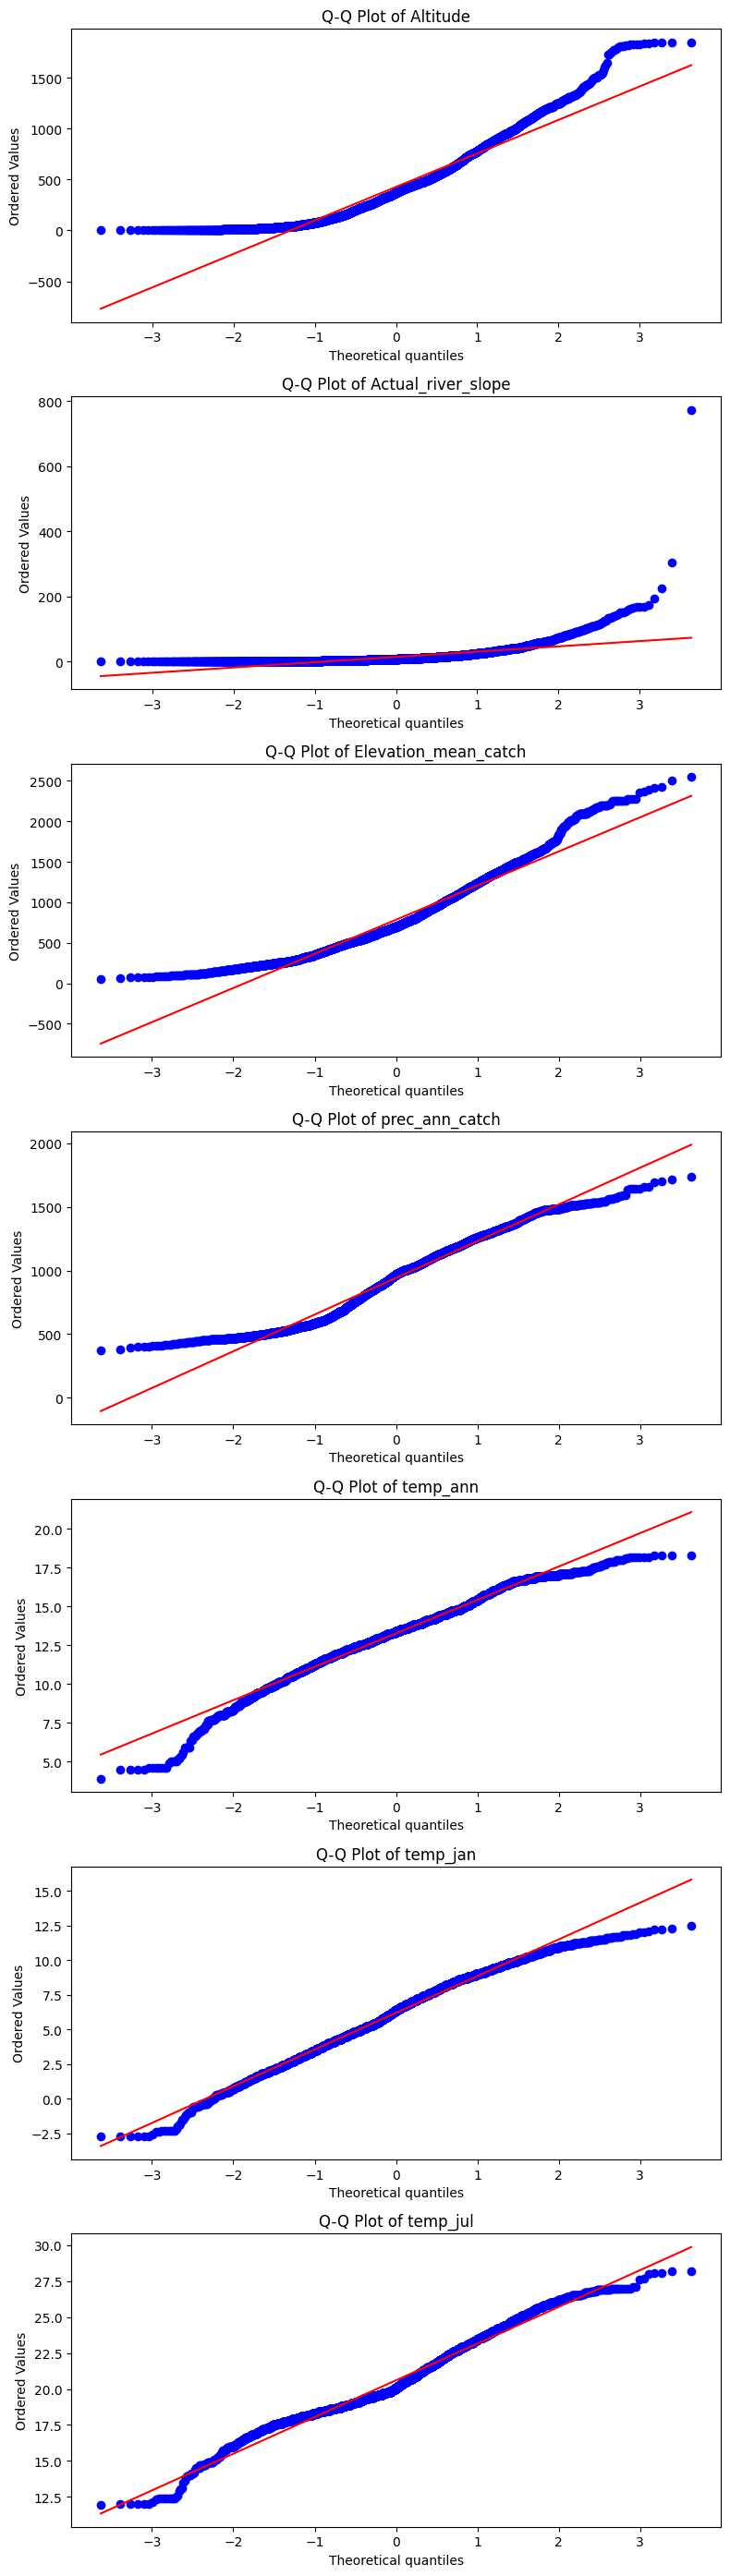

In [35]:
# Q-Q plots

fig, axes = plt.subplots(len(variables), 1, figsize=(8, 28))

for ax, var in zip(axes, variables):
    probplot(df[var].dropna(), dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot of {var}')

plt.tight_layout()
plt.show()

The visual inspection of histograms and Q-Q plots suggests that:

- Altitude: positively skewed (transformation recommended);
- Actual_river_slope: extremely positively skewed with many small values and some extreme observations (transformation strongly recommended);
- Elevation_mean_catch: moderately positively skewed (transformation may improve normality);
- prec_ann_catch: approximately symmetric (transformation not necessary);
- temp_ann, temp_jan, and temp_jul: close to normal distribution (transformation not necessary).

###3. Apply transformations and inspect new distributions

Because the skewed variables contain zeros, a log(x + 1) transformation is appropriate.

***prompt***: apply log(x + 1) transformations to the positively skewed environmental variables Altitude, Actual_river_slope and Elevation_mean_catch

In [36]:
# Log(x + 1) transformation

df['log_Altitude'] = np.log1p(df['Altitude'])
df['log_Actual_river_slope'] = np.log1p(df['Actual_river_slope'])
df['log_Elevation_mean_catch'] = np.log1p(df['Elevation_mean_catch'])

***prompt***: generate histograms with KDE curves for the transformed variables to evaluate whether the transformations improved distribution symmetry

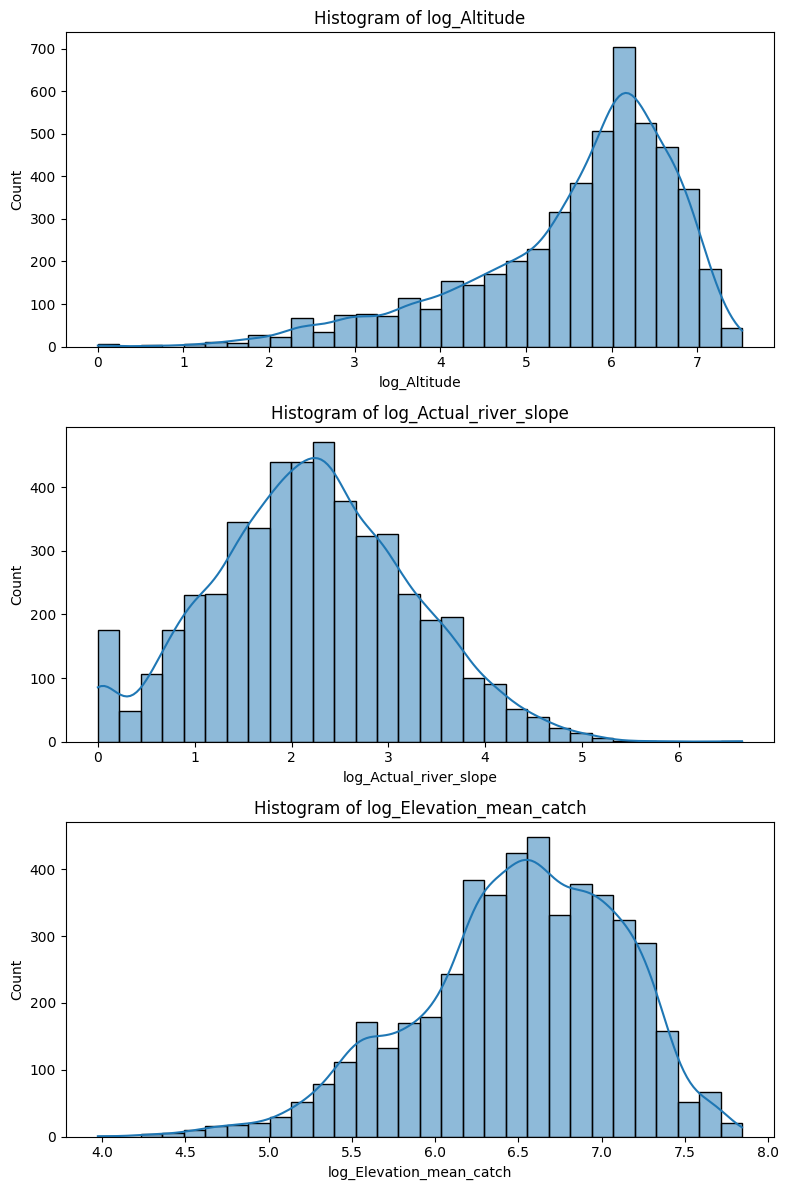

In [37]:
# Histograms of transformed variables

transformed_vars = [
    'log_Altitude',
    'log_Actual_river_slope',
    'log_Elevation_mean_catch'
]

fig, axes = plt.subplots(len(transformed_vars), 1, figsize=(8, 12))

for ax, var in zip(axes, transformed_vars):
    sns.histplot(df[var], bins=30, kde=True, ax=ax)
    ax.set_title(f'Histogram of {var}')

plt.tight_layout()
plt.show()

The log(x + 1) transformation reduced skewness considerably: distributions became more symmetric, extreme values became less influential, and the variables became more suitable for parametric analyses.

###4. Create a species richness variable

Species richness corresponds to the total number of species present at each sampling site.

The first species column is Abramis brama, and all columns to the right correspond to species presence/absence.

***prompt***: identify the position of the first species column named ‘Abramis brama’ in the dataset

In [38]:
# Locate species columns

start_col = df.columns.get_loc('Abramis brama')

***prompt***: calculate species richness by summing all species presence/absence columns row-wise and store the result in a new variable

In [39]:
# Calculate species richness

df['Species_richness'] = df.iloc[:, start_col:].sum(axis=1)

***prompt***: display summary statistics for the Species_richness variable

In [40]:
# Inspect results

df['Species_richness'].describe()

,Species_richness
count,5011.000000
mean,17.553885
std,3.056217
min,5.708050
25%,15.747113
50%,17.591460
75%,19.295860
max,42.514925


###5. Detect bivariate outliers (temp_ann vs species richness)

***prompt***: create a JointGrid scatterplot with marginal histograms to visually inspect the relationship between mean annual temperature and species richness

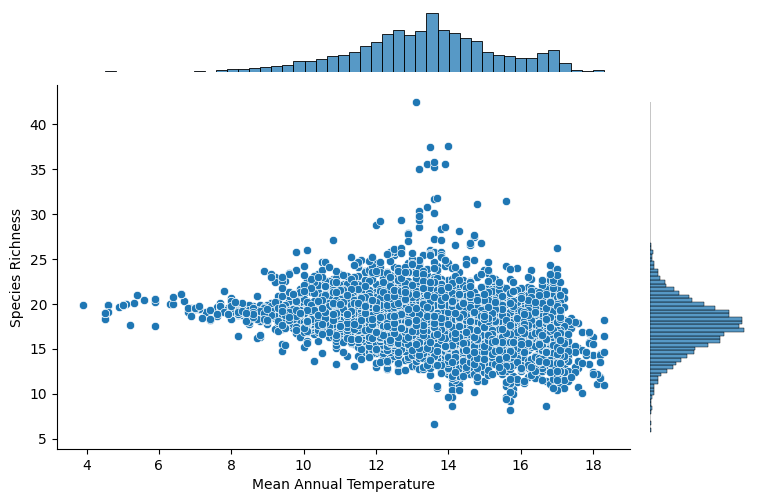

In [41]:
# Scatterplot inspection

g = sns.JointGrid(
    data=df,
    x='temp_ann',
    y='Species_richness'
)

g.plot(sns.scatterplot, sns.histplot)

g.ax_marg_x.set_axis_off()
g.ax_marg_y.set_axis_off()

g.set_axis_labels(
    xlabel='Mean Annual Temperature',
    ylabel='Species Richness'
)

g.figure.set_figwidth(8)
g.figure.set_figheight(5)

plt.show()

The relationship shows considerable dispersion and some potentially extreme observations with unusually high or low species richness relative to temperature.

***prompt***: apply a bivariate Isolation Forest to detect potential outliers in the relationship between mean annual temperature and species richness and store anomaly scores and labels

In [42]:
# Bivariate Isolation Forest

iso_data = df[['temp_ann', 'Species_richness']].dropna()

model = IsolationForest(
    n_estimators=150,
    contamination='auto',
    max_features=2,
    random_state=42
)

model.fit(iso_data[['temp_ann', 'Species_richness']])

scores = model.decision_function(
    iso_data[['temp_ann', 'Species_richness']]
)

anomaly = model.predict(
    iso_data[['temp_ann', 'Species_richness']]
)

iso_data['scores'] = scores
iso_data['anomaly'] = anomaly

***prompt***: visualize the Isolation Forest results using a JointGrid scatterplot with marginal histograms and color observations according to anomaly classification

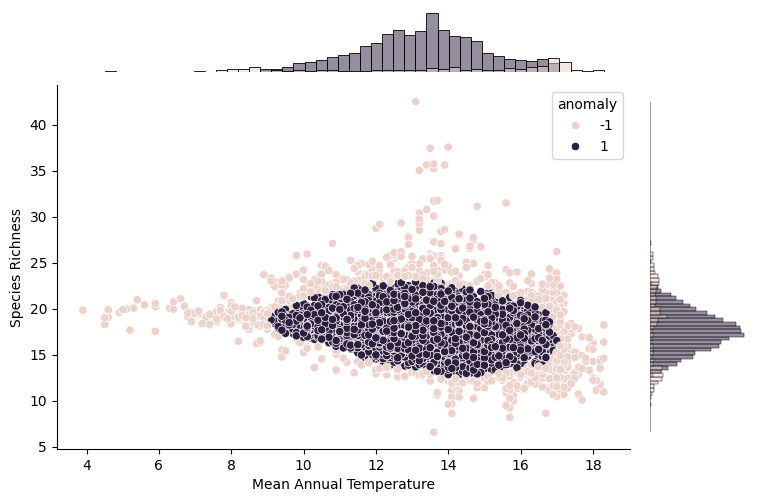

In [43]:
# Plot outliers

g = sns.JointGrid(
    data=iso_data,
    x='temp_ann',
    y='Species_richness',
    hue='anomaly'
)

g.plot(sns.scatterplot, sns.histplot)

g.ax_marg_x.set_axis_off()
g.ax_marg_y.set_axis_off()

g.set_axis_labels(
    xlabel='Mean Annual Temperature',
    ylabel='Species Richness'
)

g.figure.set_figwidth(8)
g.figure.set_figheight(5)

plt.show()

- Outliers are labeled as -1

- Normal observations are labeled as 1

The Isolation Forest identifies observations with unusual combinations of: annual temperature, and species richness.

These points may correspond to: rare ecological conditions, atypical sampling sites, measurement errors, or biologically interesting observations.

###6. Explore whether the relationship varies across countries

***prompt***: use lmplot to explore whether the relationship between mean annual temperature and species richness varies across countries with country-specific regression lines

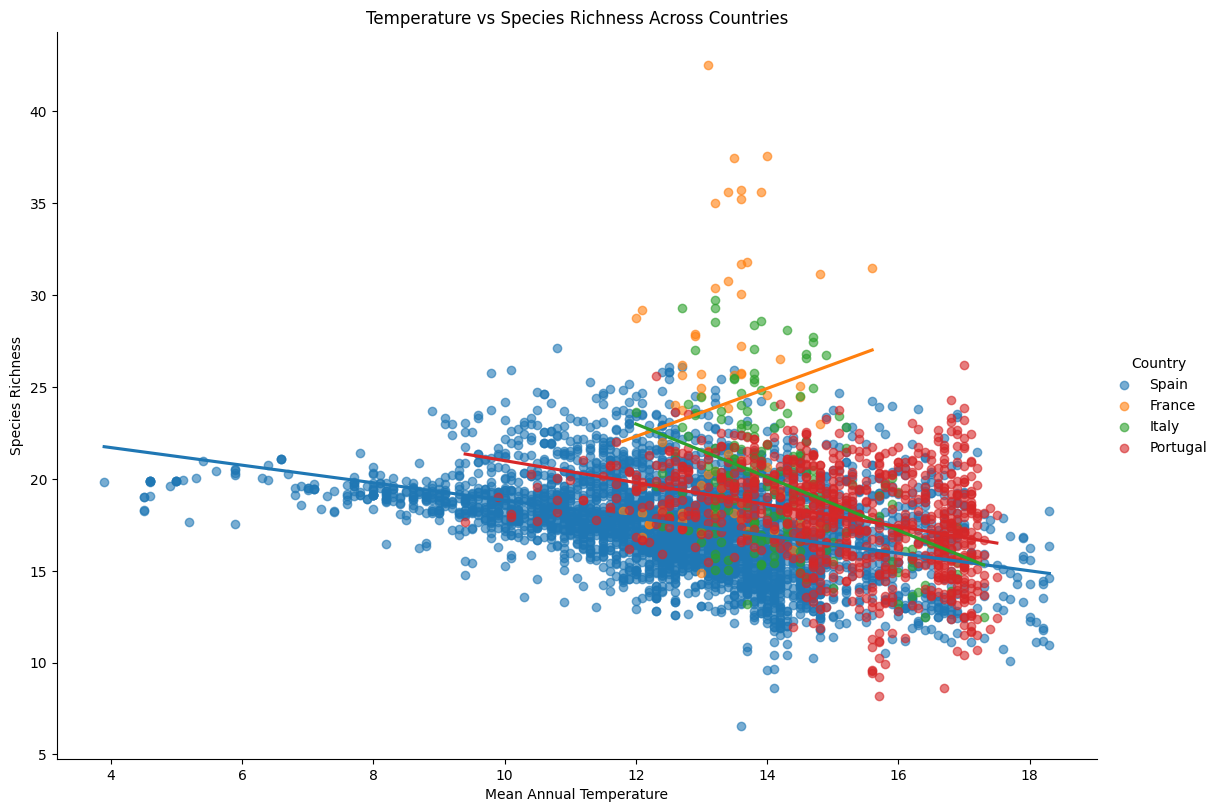

In [44]:
# Visualization by country

sns.lmplot(
    data=df,
    x='temp_ann',
    y='Species_richness',
    hue='Country',
    ci=None,
    height=8,
    aspect=1.4,
    scatter_kws={'alpha':0.6}
)

plt.xlabel('Mean Annual Temperature')
plt.ylabel('Species Richness')
plt.title('Temperature vs Species Richness Across Countries')

plt.show()

The relationship between temperature and species richness appears to differ among countries.

Possible differences include: different slopes, different temperature ranges, and different average species richness values.

This suggests that geographic or ecological factors may influence how temperature affects fish biodiversity.

**Conclusion**

- Several environmental variables showed strong positive skewness.
- Logarithmic transformations improved their distributions.
- Species richness was successfully calculated from species presence/absence data.
- Bivariate outliers between temperature and species richness were identified using Isolation Forest.
- The relationship between temperature and species richness appears to vary among countries, suggesting potential ecological and biogeographical differences.